In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
CrimeData = pd.read_csv("pa_philadelphia_2020_04_01.csv")

C:\Users\alexz\AppData\Local\Temp\ipykernel_49992\3688045367.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  CrimeData = pd.read_csv("pa_philadelphia_2020_04_01.csv")


In [3]:
Sixers = pd.read_csv('cleaned76ersData.csv')
Eagles = pd.read_csv('cleanedEaglesData.csv')
Flyers = pd.read_csv('cleanedFlyersData.csv')
Phillies = pd.read_csv('cleanedPhilliesData.csv')

In [4]:
# Verify if this is missing values are correctly removed
CrimeData = CrimeData[(~CrimeData.date.isna()) | (~CrimeData.time.isna()) | (~CrimeData.location.isna())]

In [5]:
CommonDays = CrimeData[(CrimeData.date.isin(Sixers.Date)) | (CrimeData.date.isin(Eagles.Date)) | (CrimeData.date.isin(Flyers.Date)) | (CrimeData.date.isin(Phillies.Date))]

In [6]:
CommonDays.shape[0], (CommonDays.shape[0] / CrimeData.shape[0])

(1513724, 0.8116064803098607)

In [7]:
CommonDays.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband'],
      dtype='object')

In [8]:
CommonDays.groupby('type').count()

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,subject_sex,arrest_made,outcome,contraband_found,frisk_performed,search_conducted,search_person,search_vehicle,raw_race,raw_individual_contraband,raw_vehicle_contraband
type,,,,,,,,,,,,,,,,,,,,,
pedestrian,568218,568218,568218,554412,530941,530941,568217,568215,566439,568218,567890,568218,57462,53806,568218,568218,568218,568218,568218,568218,568218
vehicular,945506,945506,945506,929002,895142,895142,945506,945505,943576,945506,945297,945506,20358,40653,945506,945506,945506,945506,945506,945506,945506


### **Common Attributes on Days with Sporting Events (Home and Away)**

In [9]:
CommonDays.groupby('arrest_made')['raw_row_number'].count()

arrest_made
False    1435904
True       77820
Name: raw_row_number, dtype: int64

In [10]:
CommonDays.groupby('contraband_found')['raw_row_number'].count()

contraband_found
False    67542
True     26917
Name: raw_row_number, dtype: int64

In [11]:
CommonDays.groupby('frisk_performed')['raw_row_number'].count()

frisk_performed
False    1378244
True      135480
Name: raw_row_number, dtype: int64

In [12]:
CommonDays.groupby('search_conducted')['raw_row_number'].count()

search_conducted
False    1419265
True       94459
Name: raw_row_number, dtype: int64

In [13]:
CommonDays.groupby('raw_race')['raw_row_number'].count()

raw_race
American Indian          4548
Asian                   32511
Black - Latino          17514
Black - Non-Latino    1010656
Unknown                 12080
White - Latino         132163
White - Non-Latino     304252
Name: raw_row_number, dtype: int64

### **Home Games Only**

In [14]:
SixersHome = Sixers[Sixers.Home == 1]
PhilliesHome = Phillies[Phillies.Home == 1]
EaglesHome = Eagles[Eagles.Home == 1]
FlyersHome = Flyers[Flyers.Home == 1]

In [15]:
HomeOnly = CrimeData[(CrimeData.date.isin(SixersHome.Date)) | (CrimeData.date.isin(EaglesHome.Date)) | (CrimeData.date.isin(FlyersHome.Date)) | (CrimeData.date.isin(PhilliesHome.Date))]

In [16]:
HomeOnly.shape[0], (HomeOnly.shape[0] / CrimeData.shape[0])

(807767, 0.4330967414009788)

In [17]:
HomeOnly.groupby('type')['raw_row_number'].count()

type
pedestrian    300545
vehicular     507222
Name: raw_row_number, dtype: int64

In [18]:
HomeOnly.groupby('arrest_made')['raw_row_number'].count()

arrest_made
False    766353
True      41414
Name: raw_row_number, dtype: int64

In [19]:
HomeOnly.groupby('contraband_found')['raw_row_number'].count()

contraband_found
False    36249
True     14466
Name: raw_row_number, dtype: int64

In [20]:
HomeOnly.groupby('frisk_performed')['raw_row_number'].count()

frisk_performed
False    735577
True      72190
Name: raw_row_number, dtype: int64

In [21]:
HomeOnly.groupby('search_conducted')['raw_row_number'].count()

search_conducted
False    757052
True      50715
Name: raw_row_number, dtype: int64

In [22]:
HomeOnly.groupby('raw_race')['raw_row_number'].count()

raw_race
American Indian         2441
Asian                  17527
Black - Latino          9249
Black - Non-Latino    539453
Unknown                 6536
White - Latino         70807
White - Non-Latino    161754
Name: raw_row_number, dtype: int64

### **Away Games Only**

In [23]:
SixersAway = Sixers[Sixers.Home == 0]
PhilliesAway = Phillies[Phillies.Home == 0]
EaglesAway = Eagles[Eagles.Home == 0]
FlyersAway = Flyers[Flyers.Home == 0]

In [24]:
AwayOnly = CrimeData[(CrimeData.date.isin(SixersAway.Date)) | (CrimeData.date.isin(EaglesAway.Date)) | (CrimeData.date.isin(FlyersAway.Date)) | (CrimeData.date.isin(PhilliesAway.Date))]

In [25]:
AwayOnly.shape[0], (AwayOnly.shape[0] / CrimeData.shape[0])

(850321, 0.45591272513586434)

In [26]:
AwayOnly.groupby('type')['raw_row_number'].count()

type
pedestrian    317742
vehicular     532579
Name: raw_row_number, dtype: int64

In [27]:
AwayOnly.groupby('arrest_made')['raw_row_number'].count()

arrest_made
False    807089
True      43232
Name: raw_row_number, dtype: int64

In [28]:
AwayOnly.groupby('contraband_found')['raw_row_number'].count()

contraband_found
False    37800
True     14874
Name: raw_row_number, dtype: int64

In [29]:
AwayOnly.groupby('frisk_performed')['raw_row_number'].count()

frisk_performed
False    774038
True      76283
Name: raw_row_number, dtype: int64

In [30]:
AwayOnly.groupby('search_conducted')['raw_row_number'].count()

search_conducted
False    797647
True      52674
Name: raw_row_number, dtype: int64

In [31]:
AwayOnly.groupby('raw_race')['raw_row_number'].count()

raw_race
American Indian         2553
Asian                  18227
Black - Latino          9838
Black - Non-Latino    567107
Unknown                 6893
White - Latino         74477
White - Non-Latino    171226
Name: raw_row_number, dtype: int64

### **No Events**

In [32]:
NoEvents = CrimeData[(~CrimeData.date.isin(Sixers.Date)) & (~CrimeData.date.isin(Eagles.Date)) & (~CrimeData.date.isin(Flyers.Date)) & (~CrimeData.date.isin(Phillies.Date))]

In [33]:
NoEvents.shape[0], (NoEvents.shape[0] / CrimeData.shape[0])

(351372, 0.18839351969013926)

In [34]:
NoEvents.groupby('type')['raw_row_number'].count()

type
pedestrian    129195
vehicular     222177
Name: raw_row_number, dtype: int64

In [35]:
NoEvents.groupby('arrest_made')['raw_row_number'].count()

arrest_made
False    333716
True      17656
Name: raw_row_number, dtype: int64

In [36]:
NoEvents.groupby('contraband_found')['raw_row_number'].count()

contraband_found
False    15683
True      6313
Name: raw_row_number, dtype: int64

In [37]:
NoEvents.groupby('frisk_performed')['raw_row_number'].count()

frisk_performed
False    319968
True      31404
Name: raw_row_number, dtype: int64

In [38]:
NoEvents.groupby('frisk_performed')['raw_row_number'].count()

frisk_performed
False    319968
True      31404
Name: raw_row_number, dtype: int64

In [39]:
NoEvents.groupby('search_conducted')['raw_row_number'].count()

search_conducted
False    329376
True      21996
Name: raw_row_number, dtype: int64

In [40]:
NoEvents.groupby('raw_race')['raw_row_number'].count()

raw_race
American Indian         1050
Asian                   7734
Black - Latino          4181
Black - Non-Latino    233593
Unknown                 2878
White - Latino         30326
White - Non-Latino     71610
Name: raw_row_number, dtype: int64

## **Visuals**

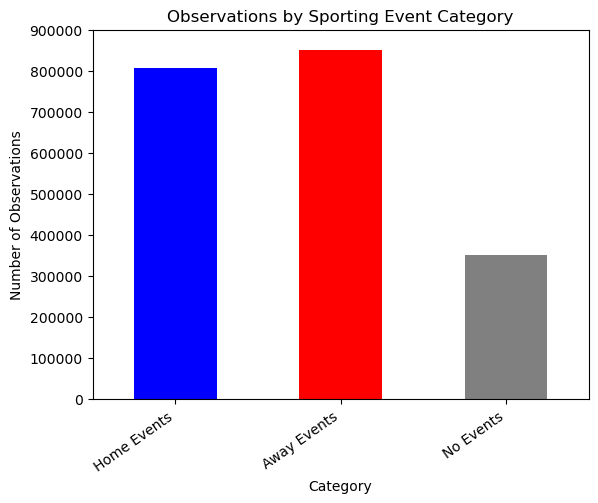

In [41]:
counts = pd.DataFrame({
    "Category": ["Home Events", "Away Events", "No Events"],
    "Observations": [HomeOnly.shape[0], AwayOnly.shape[0], NoEvents.shape[0]]
})

counts.plot(kind="bar", x="Category", y="Observations", color = ["Blue", "Red", "Gray"], legend = False)

plt.ylabel("Number of Observations")
plt.title("Observations by Sporting Event Category")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 900000)
plt.show()

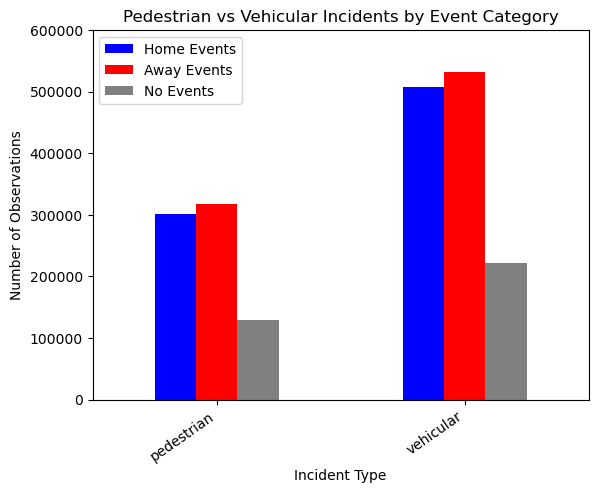

In [42]:
home_type = HomeOnly.groupby('type')['raw_row_number'].count()
away_type = AwayOnly.groupby('type')['raw_row_number'].count()
noevent_type = NoEvents.groupby('type')['raw_row_number'].count()

types = pd.DataFrame({
    "Home Events": home_type,
    "Away Events": away_type,
    "No Events": noevent_type
})

types.plot(kind="bar", color = ["Blue", "Red", "Gray"])

plt.xlabel("Incident Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 600000)
plt.title("Pedestrian vs Vehicular Incidents by Event Category")

plt.show()

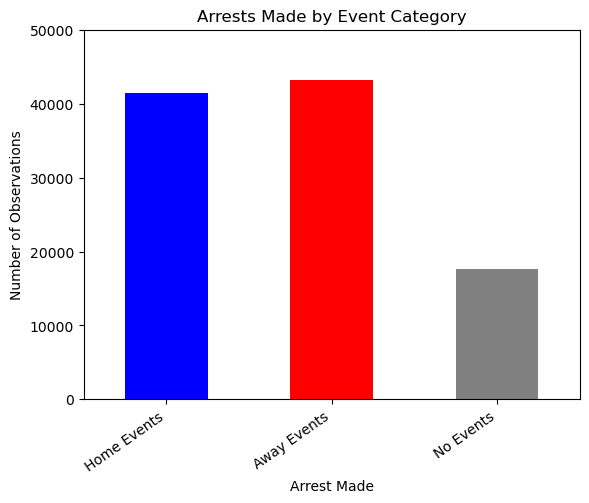

In [48]:
home_arrests = HomeOnly[HomeOnly['arrest_made'] == True].shape[0]
away_arrests = AwayOnly[AwayOnly['arrest_made'] == True].shape[0]
noevent_arrests = NoEvents[NoEvents['arrest_made'] == True].shape[0]

arrests = pd.DataFrame({
    "Category": ["Home Events", "Away Events", "No Events"],
    "Arrests": [home_arrests, away_arrests, noevent_arrests]
})

arrests.plot(kind="bar", x="Category", y="Arrests",
             color=["Blue", "Red", "Gray"], legend=False)

plt.xlabel("Arrest Made")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 50000)
plt.title("Arrests Made by Event Category")

plt.show()

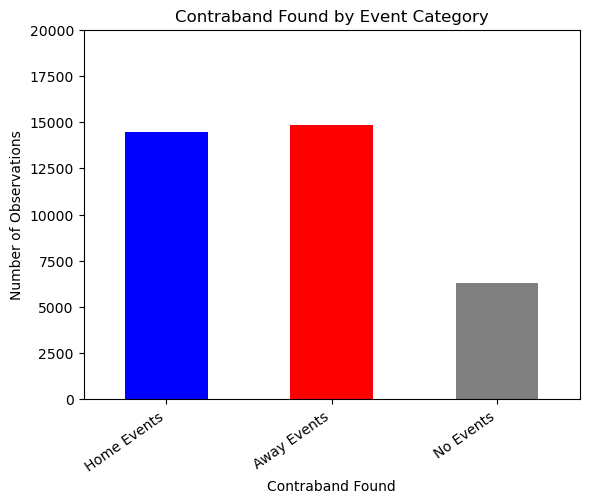

In [51]:
home_contraband = HomeOnly[HomeOnly['contraband_found'] == True].shape[0]
away_contraband = AwayOnly[AwayOnly['contraband_found'] == True].shape[0]
noevent_contraband = NoEvents[NoEvents['contraband_found'] == True].shape[0]

contraband = pd.DataFrame({
    "Category": ["Home Events", "Away Events", "No Events"],
    "Arrests": [home_contraband, away_contraband, noevent_contraband]
})

contraband.plot(kind="bar", x="Category", y="Arrests",
             color=["Blue", "Red", "Gray"], legend=False)

plt.xlabel("Contraband Found")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 20000)
plt.title("Contraband Found by Event Category")

plt.show()

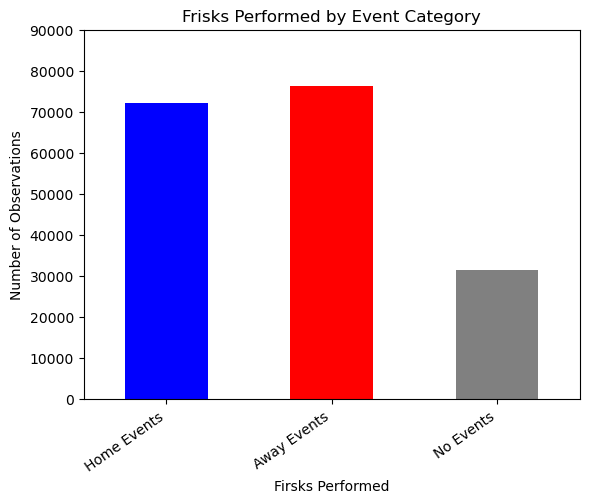

In [55]:
home_frisk = HomeOnly[HomeOnly['frisk_performed'] == True].shape[0]
away_frisk = AwayOnly[AwayOnly['frisk_performed'] == True].shape[0]
noevent_frisk = NoEvents[NoEvents['frisk_performed'] == True].shape[0]

frisk = pd.DataFrame({
    "Category": ["Home Events", "Away Events", "No Events"],
    "Arrests": [home_frisk, away_frisk, noevent_frisk]
})

frisk.plot(kind="bar", x="Category", y="Arrests",
             color=["Blue", "Red", "Gray"], legend=False)

plt.xlabel("Firsks Performed")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 90000)
plt.title("Frisks Performed by Event Category")

plt.show()

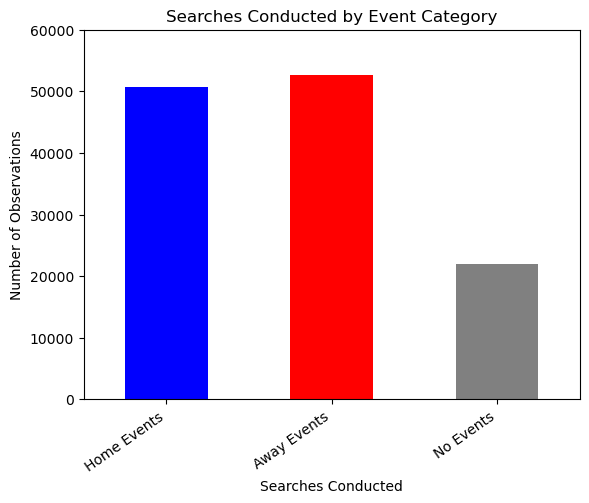

In [57]:
home_search = HomeOnly[HomeOnly['search_conducted'] == True].shape[0]
away_search = AwayOnly[AwayOnly['search_conducted'] == True].shape[0]
noevent_search = NoEvents[NoEvents['search_conducted'] == True].shape[0]

search = pd.DataFrame({
    "Category": ["Home Events", "Away Events", "No Events"],
    "Arrests": [home_search, away_search, noevent_search]
})

search.plot(kind="bar", x="Category", y="Arrests",
             color=["Blue", "Red", "Gray"], legend=False)

plt.xlabel("Searches Conducted")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.ylim(0, 60000)
plt.title("Searches Conducted by Event Category")

plt.show()

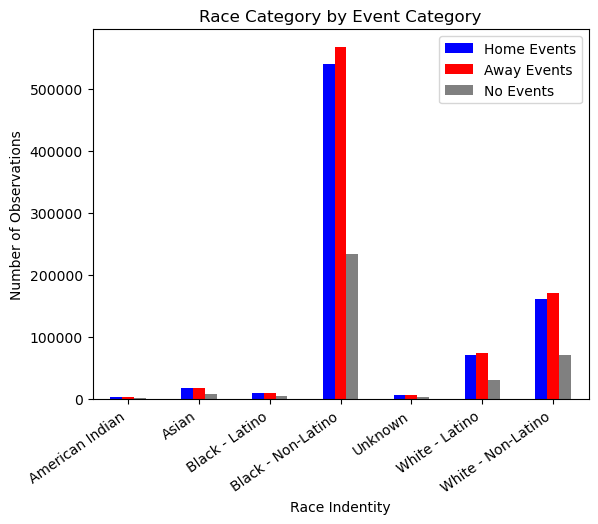

In [60]:
home_race = HomeOnly.groupby('raw_race')['raw_row_number'].count()
away_race = AwayOnly.groupby('raw_race')['raw_row_number'].count()
noevent_race = NoEvents.groupby('raw_race')['raw_row_number'].count()

race = pd.DataFrame({
    "Home Events": home_race,
    "Away Events": away_race,
    "No Events": noevent_race
})

race.plot(kind="bar", color = ["Blue", "Red", "Gray"])

plt.xlabel("Race Indentity")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha = "right", fontsize = 10)   
plt.title("Race Category by Event Category")

plt.show()